In [1]:
import scipy
from src.data_loader import load_training_data
from src.preprocessing import preprocess, highpass_filter, bandpass_filter
import config
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.feature_extraction import extract_eog_features

In [2]:
edf_path = "../data/training/R2.edf"
xml_path = "../data/training/R2.xml"
data,_,channel_info= load_training_data(edf_path, xml_path)
preprocessed_data = preprocess(data,channel_info, config)
epoch_eeg = preprocessed_data['eeg'][0,0,:]


Loading training data from ../data/training/R2.edf and ../data/training/R2.xml...
Identified channels:
  EEG: ['EEG(sec)', 'EEG']
  EOG: ['EOG(L)', 'EOG(R)']
  EMG: ['EMG']
  EEG: 2 channels, 3750 samples/epoch, 125.0 Hz
  EOG: 2 channels, 3750 samples/epoch, 125.0 Hz
  EMG: 1 channels, 3750 samples/epoch, 125.0 Hz

Loaded 1078 epochs (8.98 hours)
Sleep stage distribution:
  Wake: 715 epochs (66.3%)
  N1: 3 epochs (0.3%)
  N2: 238 epochs (22.1%)
  N3: 61 epochs (5.7%)
  REM: 61 epochs (5.7%)
Preprocessing data for iteration 4...
Processing multi-channel data (EEG + EOG + EMG)
EEG sampling frequency: 125.0 Hz
Processing EEG channel 1
Processing EEG channel 2
EOG sampling frequency: 125.0 Hz
Processing EOG channel 1
Processing EOG channel 2
EMG sampling frequency: 125.0 Hz
Processing EMG
EMG Adaptive Filter: Threshold set at 0.0000 uV
EMG Artifacts: Stricter filtering applied to 236/1078 epochs.
Multi-channel preprocessing applied to EEG + EOG + EMG


In [3]:
channel_info

{'epoch_length': 30,
 'eeg_names': ['EEG(sec)', 'EEG'],
 'eeg_fs': 125.0,
 'eog_names': ['EOG(L)', 'EOG(R)'],
 'eog_fs': 125.0,
 'emg_names': ['EMG'],
 'emg_fs': 125.0}

In [4]:
epoch_eog = preprocessed_data['eog']


In [5]:
epoch_eog[0].shape

(2, 3750)

In [6]:
epoch_eog_L = data['eog'][0,0,:]
epoch_eog_L

array([2.10874020e-05, 5.92759911e-05, 4.11126621e-05, ...,
       2.87631184e-05, 8.88985260e-06, 5.30161443e-07], shape=(3750,))

In [7]:
epoch_eog_R = data['eog'][0,1,:]
epoch_eog_R

array([ 1.81235115e-05, -8.39950865e-06,  2.24009827e-06, ...,
        2.08974090e-05,  2.13913907e-05,  2.20373669e-05], shape=(3750,))

In [8]:
features = extract_eog_features([epoch_eog_L, epoch_eog_R], 125)

In [15]:
len(features.values()) == 10

True

In [8]:
channel_info["eog_fs"]

125.0

In [9]:
high_R = highpass_filter(epoch_eog_R, 0.5, channel_info["eog_fs"])
high_L = highpass_filter(epoch_eog_L, 0.5, channel_info["eog_fs"])

In [10]:
filtered_eog_R = bandpass_filter(epoch_eog_R,0.5,5,channel_info["eog_fs"],4)
filtered_eog_L = bandpass_filter(epoch_eog_L,0.5,5,channel_info["eog_fs"],4)


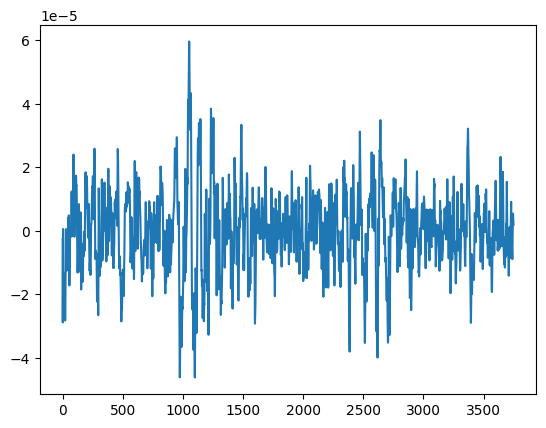

In [12]:
plt.plot(high_R)

In [114]:
neg_product = -(filtered_eog_L * filtered_eog_R)

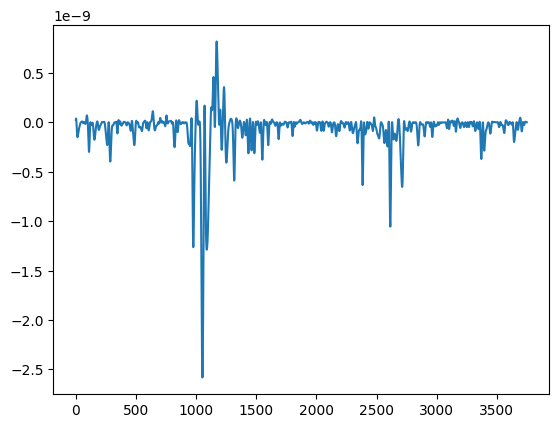

In [116]:
plt.plot(neg_product)

In [117]:
from scipy.signal import find_peaks

In [118]:
1/125 * 0.5

0.004

In [122]:
peaks = find_peaks(neg_product,distance = 75, height = 0) # finds peaks within 0.5 secs of each other, might need to change if fs changes

In [124]:
peaks

(array([   2,   92,  178,  273,  354,  502,  639,  753,  858, 1004, 1170,
        1335, 1448, 1631, 1789, 1866, 1947, 2050, 2205, 2288, 2371, 2480,
        2601, 2683, 2774, 2862, 2976, 3094, 3173, 3309, 3462, 3576, 3694]),
 {'peak_heights': array([3.85466409e-11, 7.02354118e-11, 9.42194034e-12, 6.81390311e-13,
         2.22881509e-11, 1.61352784e-11, 1.12138517e-10, 6.97082277e-11,
         2.15745829e-11, 2.18349257e-10, 8.18227230e-10, 4.04547910e-11,
         3.86181682e-11, 2.90686603e-11, 6.88797382e-12, 2.51591297e-11,
         1.71721156e-11, 9.09918567e-12, 1.29813375e-11, 2.92882359e-12,
         1.06249516e-11, 5.01749400e-11, 6.46532319e-12, 3.29230163e-11,
         8.68171700e-12, 2.26695939e-12, 6.17115373e-12, 2.71134991e-11,
         3.88254840e-11, 1.07908466e-11, 7.04347111e-12, 2.12632448e-11,
         4.55955748e-11])})

In [125]:
peak = peaks[0]
peak = np.array(peak)


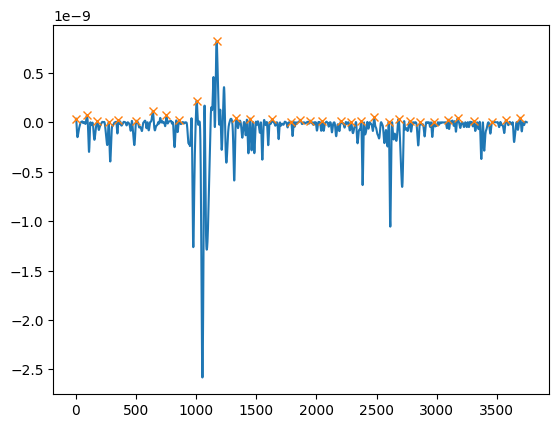

In [126]:
plt.plot(neg_product)
plt.plot(peak, neg_product[peak], "x")
